In [ ]:
import pandas as pd

In [ ]:
inflation_rates = {
    2016: 1.00,  # Базовый год (инфляция = 0%)
    2017: 1.05,   # +5%
    2018: 1.02,   # +2%
    2019: 1.05,   # +5%
    2020: 1.024,  # +2.4%
    2021: 1.05,   # +5%
    2022: 1.08,   # +8%
    2023: 1.11,   # +11%
    2024: 1.07    # +7%
}

In [ ]:
cumulative_inflation = {2016: 1.0}  # Базовый год
current_cumulative = 1.0

# Рассчитываем множители для умножения
for year in sorted(inflation_rates.keys()):
    if year == 2016:
        continue
    current_cumulative *= inflation_rates[year]
    cumulative_inflation[year] = current_cumulative  # Накопленный множитель

print("Кумулятивные коэффициенты инфляции:")
print(cumulative_inflation)

Кумулятивные коэффициенты инфляции:
{2016: 1.0, 2017: 1.05, 2018: 1.0710000000000002, 2019: 1.1245500000000002, 2020: 1.1515392000000002, 2021: 1.2091161600000002, 2022: 1.3058454528000003, 2023: 1.4494884526080005, 2024: 1.5509526442905606}


In [ ]:
# Функция для корректировки
def adjust_price(row):
    year = row['Год']
    original_price = row['Стоимость']
    return original_price * cumulative_inflation.get(year, 1.0)  # Если год не найден, множитель = 1.0

# Заменяем исходные цены
df['Стоимость'] = df.apply(adjust_price, axis=1)

In [ ]:
adjusted_prices = df.groupby('Год')['Стоимость'].mean().round(2)
print("Средние цены после корректировки:")
print(adjusted_prices)

Средние цены после корректировки:
Год
2016    255756.61
2017    265704.20
2019    310128.02
2020    310566.67
2021    300540.81
2022    332989.58
2023    298029.35
2024    374496.89
Name: Стоимость, dtype: float64


In [ ]:
df.to_csv('universities_with_okso_advanced.csv', index=False)

In [ ]:
# df = pd.read_csv("/content/universities_with_okso.csv")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.3968 - mae: 0.4502 - val_loss: 0.2203 - val_mae: 0.3147
Epoch 2/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.2184 - mae: 0.3136 - val_loss: 0.1733 - val_mae: 0.2583
Epoch 3/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.1743 - mae: 0.2695 - val_loss: 0.1472 - val_mae: 0.2346
Epoch 4/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.1534 - mae: 0.2471 - val_loss: 0.1242 - val_mae: 0.2027
Epoch 5/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.1363 - mae: 0.2293 - val_loss: 0.1125 - val_mae: 0.1907
Epoch 6/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - loss: 0.1263 - mae: 0.2152 - val_loss: 0.1054 - val_mae: 0.1825
Epoch 7/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.1159 - mae: 0.2028 - val_loss: 0.1033 - val_mae: 0.1775
Epoch 8/50
2006/2006 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.1138 - mae: 0.1974 - val_loss: 0.0934 - val_mae: 0.1596
Epoch 9/50
2006/2006 ━━━━━━━━━

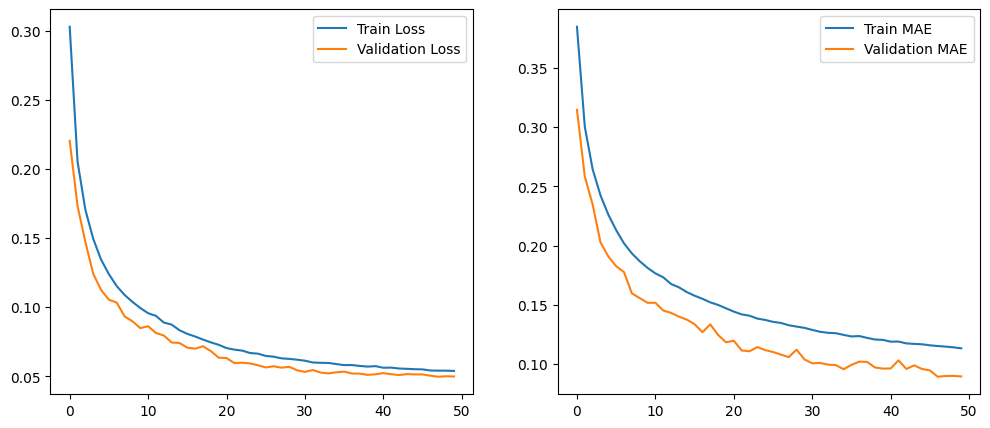

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Загрузка и подготовка данных
# df = pd.read_csv("/content/new_all_universities_data_s_0_0_200.csv")
df = df[df['Стоимость'] != 0].copy()

# Преобразование даты
df['Дата архивации'] = pd.to_datetime(df['Дата архивации'])
df['Год'] = df['Дата архивации'].dt.year
df['Месяц'] = df['Дата архивации'].dt.month
df['День'] = df['Дата архивации'].dt.day

# Определение признаков
numerical_features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места']
categorical_features = ['Программа', 'Вуз']
target = 'Стоимость'

# Препроцессинг
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_processed = preprocessor.fit_transform(df[numerical_features + categorical_features])
y = df[target].values.reshape(-1, 1)

# Масштабирование целевой переменной
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Формирование 3D-тензора (n_samples, 1, n_features)
X_reshaped = np.expand_dims(X_processed, axis=1)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_scaled, test_size=0.2, random_state=42
)

# Упрощенная LSTM модель
model = Sequential([
    LSTM(128, input_shape=(1, X_processed.shape[1]), return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Обучение с ранней остановкой
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# Визуализация
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.show()

In [ ]:
print(f"MAE составляет {mae_value / y.mean() * 100:.1f}% от средней цены")

NameError: name 'mae_value' is not defined

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

metrics = {
    "MAE (рубли)": mean_absolute_error(y_test_original, y_pred),
    "MSE (рубли²)": mean_squared_error(y_test_original, y_pred),
    "RMSE (рубли)": np.sqrt(mean_squared_error(y_test_original, y_pred)),
    "R²": r2_score(y_test_original, y_pred),

    # Метрики в масштабированном виде (для сравнения)
    "MAE (scaled)": mean_absolute_error(y_test, y_pred_scaled),
    "MSE (scaled)": mean_squared_error(y_test, y_pred_scaled),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

502/502 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE (рубли): 14226.5776
MSE (рубли²): 1249890312.6427
RMSE (рубли): 35353.7878
R²: 0.9508
MAE (scaled): 0.0897
MSE (scaled): 0.0497


In [ ]:
from sklearn.pipeline import Pipeline
import joblib
import pickle
from tensorflow.keras.models import load_model

# Определяем список признаков, который использовался при обучении
features = ['Год', 'Месяц', 'День', 'Проходной балл', 'Бюджетные места', 'Программа', 'Вуз']
# Сохраняем ВЕСЬ препроцессор
joblib.dump(preprocessor, 'full_preprocessor_v2.joblib')

# Сохраняем модель
model.save('lstm_model_v2.keras')

# Сохраняем scaler для целевой переменной
joblib.dump(scaler_y, 'scaler_y_v2.joblib')

# Сохраняем список признаков
with open('features_list_v2.pkl', 'wb') as f:
    pickle.dump(features, f)

In [ ]:
def load_model_components():
    try:
        # Загружаем в обратном порядке
        with open('features_list_v2.pkl', 'rb') as f:
            features = pickle.load(f)

        preprocessor = joblib.load('full_preprocessor_v2.joblib')
        model = load_model('lstm_model_v2.keras')
        scaler_y = joblib.load('scaler_y_v2.joblib')

        return model, preprocessor, scaler_y, features
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        raise

In [ ]:
def predict_cost(input_dict, model, preprocessor, scaler_y, features):
    """
    input_dict: словарь с данными вида {
        'Год': 2025,
        'Месяц': 6,
        'День': 1,
        'Проходной балл': 85,
        'Бюджетные места': 20,
        'Программа': '02.09.03.03',
        'Вуз': 'МГУ'
    }
    """
    try:
        # Создаем DataFrame с правильным порядком колонок
        input_df = pd.DataFrame([input_dict])[features]

        # Преобразуем данные
        X_processed = preprocessor.transform(input_df)
        if hasattr(X_processed, 'toarray'):
            X_processed = X_processed.toarray()

        # Проверяем размерность
        if X_processed.shape[1] != model.input_shape[2]:
            raise ValueError(
                f"Несоответствие размеров: модель ожидает {model.input_shape[2]} признаков, "
                f"получено {X_processed.shape[1]}. Проверьте препроцессор."
            )

        X_reshaped = np.expand_dims(X_processed, axis=1)
        y_pred = scaler_y.inverse_transform(model.predict(X_reshaped))
        return y_pred[0][0]
    except Exception as e:
        print(f"Ошибка предсказания: {e}")
        return None

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
# Загрузка компонентов
model, preprocessor, scaler_y, features = load_model_components()

# Входные данные
input_data = {
    'Год': 2024,
    'Месяц': 6,
    'День': 1,
    'Проходной балл': 50,
    'Бюджетные места': 20,
    'Программа': '5.09.03.03',
    'Вуз': 'Московский университет имени С.Ю. Витте'
}

# Предсказание
prediction = predict_cost(input_data, model, preprocessor, scaler_y, features)
if prediction is not None:
    print(f"Предсказанная стоимость: {prediction:.2f} руб.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
Предсказанная стоимость: 102607.98 руб.
